In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
all_data=pd.read_csv("stock_data.csv")

In [3]:
all_data["Date"]=pd.to_datetime(all_data["Date"])

In [4]:
all_data.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,Price_change,20MA,50MA,Daily_Return,Volatility
0,2020-01-02,151.829529,160.619995,160.729996,158.330002,158.779999,22622100,MSFT,1.839996,NaN,NaN,NaN,NaN
1,2020-01-03,149.939026,158.619995,159.949997,158.059998,158.320007,21116200,MSFT,0.299988,NaN,NaN,-1.245175,NaN
2,2020-01-06,150.326569,159.029999,159.100006,156.509995,157.080002,20813700,MSFT,1.949997,NaN,NaN,0.258482,NaN
3,2020-01-07,148.955917,157.580002,159.669998,157.320007,159.320007,21634100,MSFT,-1.740005,NaN,NaN,-0.911776,NaN
4,2020-01-08,151.328568,160.089996,160.800003,157.949997,158.929993,27746500,MSFT,1.160004,NaN,NaN,1.592838,NaN


In [5]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7535 entries, 0 to 7534
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          7535 non-null   datetime64[ns]
 1   Adj Close     7535 non-null   float64       
 2   Close         7535 non-null   float64       
 3   High          7535 non-null   float64       
 4   Low           7535 non-null   float64       
 5   Open          7535 non-null   float64       
 6   Volume        7535 non-null   int64         
 7   Ticker        7535 non-null   object        
 8   Price_change  7535 non-null   float64       
 9   20MA          7440 non-null   float64       
 10  50MA          7440 non-null   float64       
 11  Daily_Return  7530 non-null   float64       
 12  Volatility    7435 non-null   float64       
dtypes: datetime64[ns](1), float64(10), int64(1), object(1)
memory usage: 765.4+ KB


In [6]:
all_data.isnull().sum()

Date              0
Adj Close         0
Close             0
High              0
Low               0
Open              0
Volume            0
Ticker            0
Price_change      0
20MA             95
50MA             95
Daily_Return      5
Volatility      100
dtype: int64

In [7]:
all_data.describe()

,Date,Adj Close,Close,High,Low,Open,Volume,Price_change,20MA,50MA,Daily_Return,Volatility
count,7535,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7.535000e+03,7535.000000,7440.000000,7440.000000,7530.000000,7435.000000
mean,2022-12-29 22:34:00.079628544,165.656114,167.910356,169.734527,165.947102,167.857472,1.239601e+08,0.052884,167.638699,5.157892,0.137665,2.139641
min,2020-01-02 00:00:00,4.885128,4.910000,5.248500,4.517000,5.002500,5.855900e+06,-21.729980,5.918063,0.110537,-18.452086,0.596026
25%,2021-06-30 00:00:00,103.560509,104.192501,105.571751,102.349998,103.885002,2.969040e+07,-1.189987,104.830126,2.833249,-1.008590,1.428015
50%,2022-12-28 00:00:00,153.142502,154.500000,156.445496,152.274994,154.289993,5.090730e+07,0.081001,154.351850,4.572261,0.135319,1.880172
75%,2024-07-01 00:00:00,208.608963,213.220001,215.224998,210.979996,213.330002,1.157820e+08,1.399994,213.022251,6.802568,1.295496,2.525566
max,2025-12-30 00:00:00,538.658508,542.070007,555.450012,540.770020,555.229980,1.543911e+09,36.949982,521.743495,32.410179,24.369636,8.702213
std,NaN,104.738322,106.499819,107.289721,105.640214,106.512030,1.709207e+08,2.811508,105.897913,3.364351,2.365530,1.059845


In [8]:
#Highest average closing price

avg_close = all_data.groupby("Ticker")["Close"].mean().sort_values(ascending=False)

print(avg_close)

Ticker
MSFT     322.429423
AAPL     166.992130
AMZN     158.429565
GOOGL    134.178340
NVDA      57.522323
Name: Close, dtype: float64


In [ ]:
Microsoft had the highest average closing price among the selected companies, 
indicating a higher nominal share price over the analysis period.

In [9]:
#Highest average daily return

avg_return= all_data.groupby("Ticker")["Daily_Return"].mean().sort_values(ascending=False)

print(avg_return)

Ticker
NVDA     0.284588
GOOGL    0.122107
AAPL     0.105779
MSFT     0.091068
AMZN     0.084783
Name: Daily_Return, dtype: float64


In [ ]:
NVDA has the highest average return among the selected companies,
due to the tech and AI expansions.    

In [58]:
#MOST VOLATILE STOCK

volatility = (
    all_data
    .groupby("Ticker")["Daily_Return"].std().sort_values(ascending=False)
)

print(volatility)

Ticker
NVDA     3.351338
AMZN     2.249703
GOOGL    2.046349
AAPL     2.004280
MSFT     1.862358
Name: Daily_Return, dtype: float64


In [ ]:
higher volatility means Nvidias positive daily jumps are much larger, 
pushing its mathematical daily average significantly higher than all selected companies.

In [12]:
#HIGHEST TRADING VOLUME

volume=(all_data.groupby("Ticker")["Volume"].mean().sort_values(ascending=False))

print(volume)

Ticker
NVDA     4.094942e+08
AAPL     8.457532e+07
AMZN     6.452822e+07
GOOGL    3.362545e+07
MSFT     2.757735e+07
Name: Volume, dtype: float64


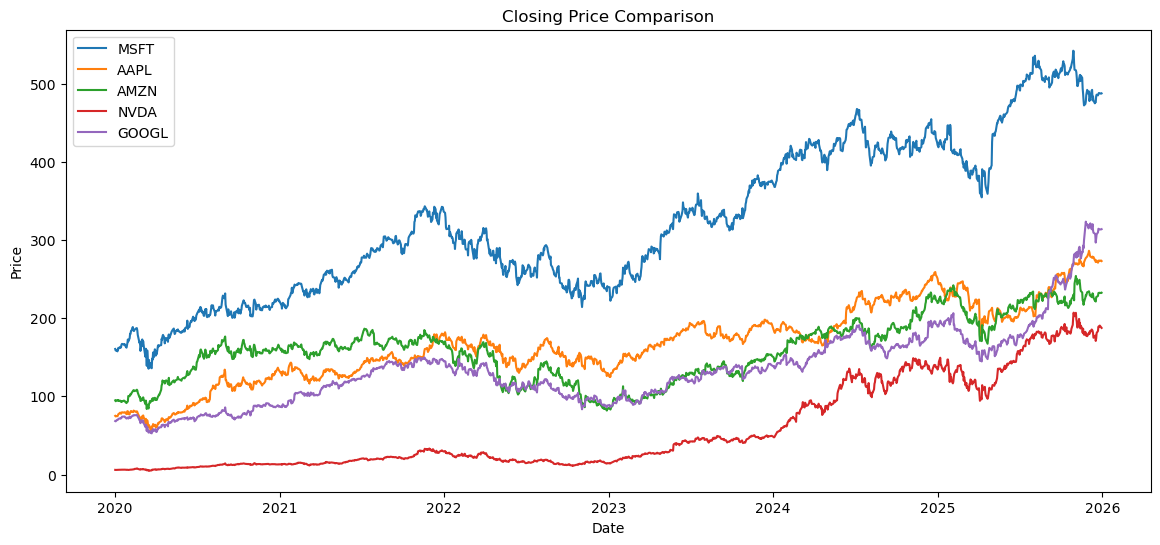

In [14]:
#CLOSING PRICE TREND

plt.figure(figsize=(14,6))

for ticker in all_data["Ticker"].unique():

    stock = all_data[all_data["Ticker"] == ticker]

    plt.plot(
        stock["Date"],
        stock["Close"],
        label=ticker
    )

plt.title("Closing Price Comparison")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.show()

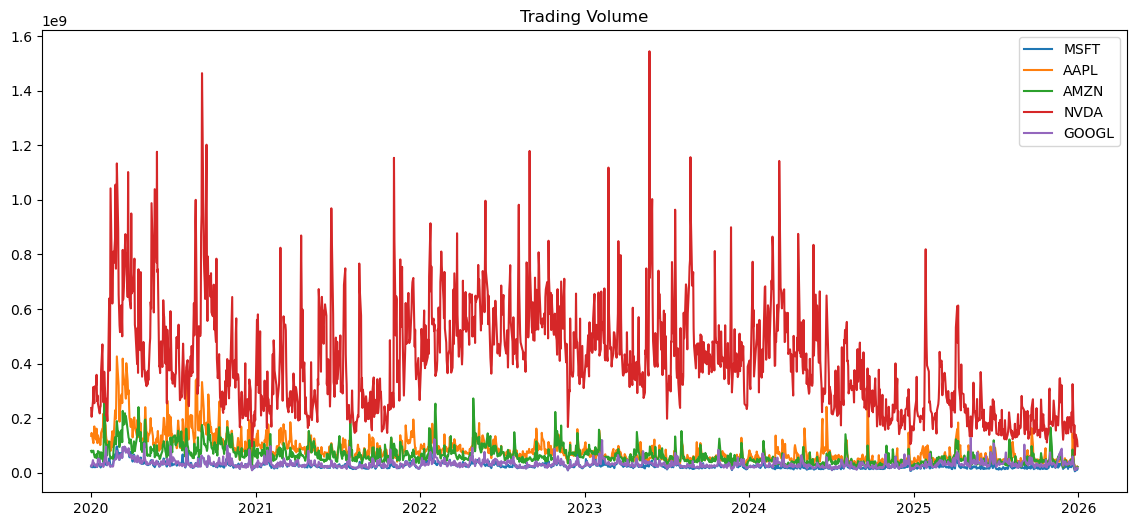

In [15]:
#VOLUME COMPARISON

plt.figure(figsize=(14,6))

for ticker in all_data["Ticker"].unique():

    stock = all_data[all_data["Ticker"] == ticker]

    plt.plot(
        stock["Date"],
        stock["Volume"],
        label=ticker
    )

plt.legend()

plt.title("Trading Volume")

plt.show()

In [19]:
#MOVING AVERAGE ANALYSIS - MICROSOFT

msft = all_data[
    all_data["Ticker"] == "MSFT"
]

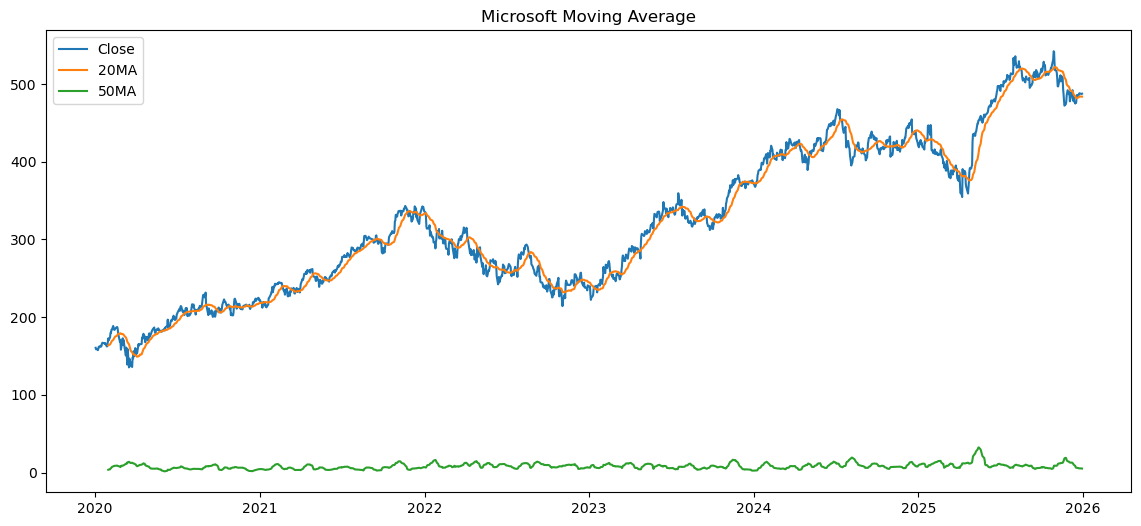

In [20]:
plt.figure(figsize=(14,6))

plt.plot(msft["Date"], msft["Close"], label="Close")

plt.plot(msft["Date"], msft["20MA"], label="20MA")

plt.plot(msft["Date"], msft["50MA"], label="50MA")

plt.legend()

plt.title("Microsoft Moving Average")

plt.show()

In [35]:
#MOVING AVERAGE ANALYSIS - AMAZON
amzn= all_data[
    all_data["Ticker"] == "AMZN"
]

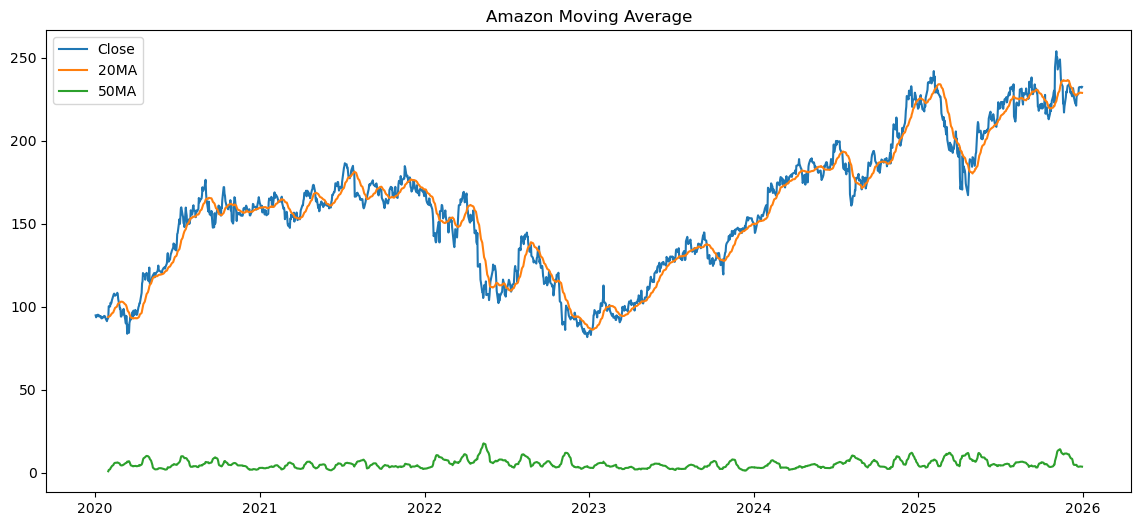

In [37]:
plt.figure(figsize=(14,6))

plt.plot(amzn["Date"], amzn["Close"], label="Close")

plt.plot(amzn["Date"], amzn["20MA"], label="20MA")

plt.plot(amzn["Date"], amzn["50MA"], label="50MA")

plt.legend()

plt.title("Amazon Moving Average")

plt.show()

In [25]:
all_data.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,Price_change,20MA,50MA,Daily_Return,Volatility
0,2020-01-02,151.829529,160.619995,160.729996,158.330002,158.779999,22622100,MSFT,1.839996,NaN,NaN,NaN,NaN
1,2020-01-03,149.939026,158.619995,159.949997,158.059998,158.320007,21116200,MSFT,0.299988,NaN,NaN,-1.245175,NaN
2,2020-01-06,150.326569,159.029999,159.100006,156.509995,157.080002,20813700,MSFT,1.949997,NaN,NaN,0.258482,NaN
3,2020-01-07,148.955917,157.580002,159.669998,157.320007,159.320007,21634100,MSFT,-1.740005,NaN,NaN,-0.911776,NaN
4,2020-01-08,151.328568,160.089996,160.800003,157.949997,158.929993,27746500,MSFT,1.160004,NaN,NaN,1.592838,NaN


In [38]:
aapl = all_data[
    all_data["Ticker"] == "AAPL"
]

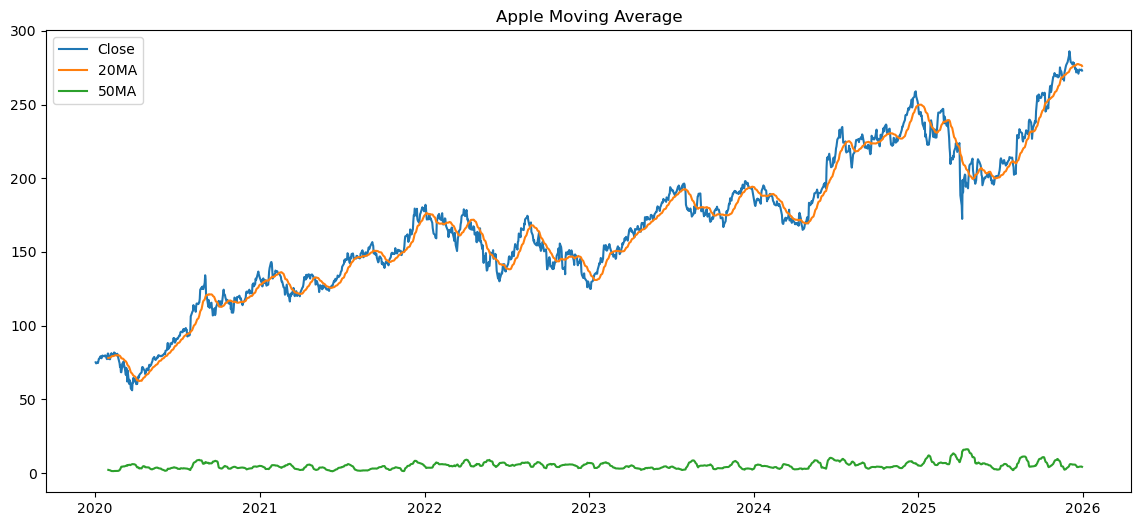

In [39]:
plt.figure(figsize=(14,6))

plt.plot(aapl["Date"], aapl["Close"], label="Close")

plt.plot(aapl["Date"], aapl["20MA"], label="20MA")

plt.plot(aapl["Date"], aapl["50MA"], label="50MA")

plt.legend()

plt.title("Apple Moving Average")

plt.show()

In [40]:
googl = all_data[
    all_data["Ticker"] == "GOOGL"
]

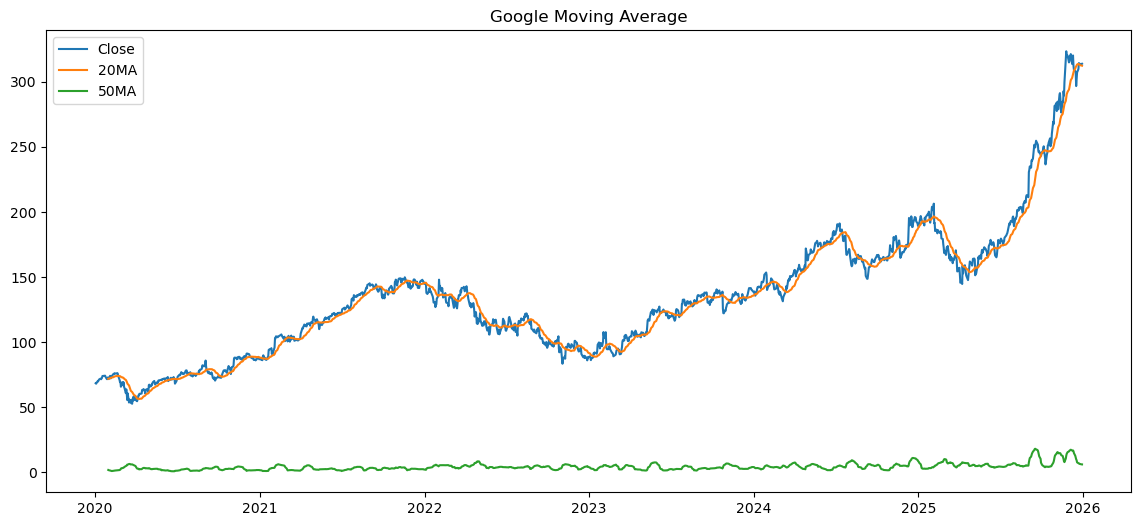

In [42]:
plt.figure(figsize=(14,6))

plt.plot(googl["Date"], googl["Close"], label="Close")

plt.plot(googl["Date"], googl["20MA"], label="20MA")

plt.plot(googl["Date"], googl["50MA"], label="50MA")

plt.legend()

plt.title("Google Moving Average")

plt.show()

In [43]:
all_data.groupby("Ticker").get_group("NVDA")

,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,Price_change,20MA,50MA,Daily_Return,Volatility
4521,2020-01-02,5.963804,5.997750,5.997750,5.918000,5.968750,237536000,NVDA,0.029000,NaN,NaN,NaN,NaN
4522,2020-01-03,5.868346,5.901750,5.945750,5.852500,5.877500,205384000,NVDA,0.024250,NaN,NaN,-1.600596,NaN
4523,2020-01-06,5.892958,5.926500,5.931750,5.781750,5.808000,262636000,NVDA,0.118500,NaN,NaN,0.419363,NaN
4524,2020-01-07,5.964301,5.998250,6.044250,5.909750,5.955000,314856000,NVDA,0.043250,NaN,NaN,1.210667,NaN
4525,2020-01-08,5.975487,6.009500,6.051000,5.953750,5.994000,277108000,NVDA,0.015500,NaN,NaN,0.187555,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6023,2025-12-23,188.979507,189.210007,189.330002,182.899994,182.970001,174873600,NVDA,6.240005,180.253501,4.366961,3.005065,2.088034
6024,2025-12-24,188.380234,188.610001,188.910004,186.589996,187.940002,65528500,NVDA,0.669998,180.793001,4.704000,-0.317111,1.987543
6025,2025-12-26,190.297897,190.529999,192.690002,188.000000,189.919998,139740300,NVDA,0.610001,181.306501,5.179291,1.017973,1.979177
6026,2025-12-29,187.990707,188.220001,188.759995,185.910004,187.710007,120006100,NVDA,0.509995,181.867501,5.294645,-1.212406,1.950090


In [44]:
nvda = all_data[
    all_data["Ticker"] == "NVDA"
]

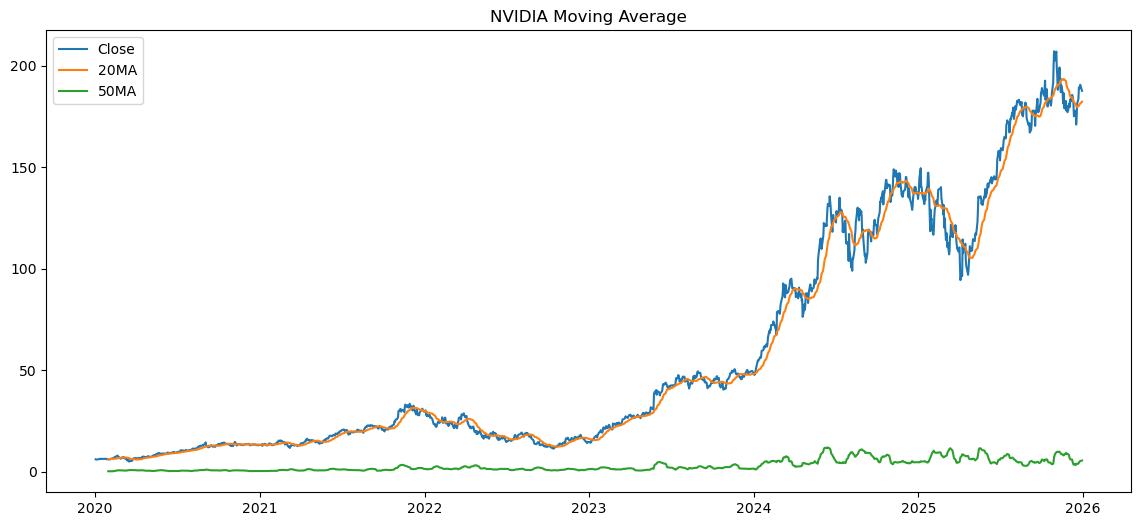

In [47]:
plt.figure(figsize=(14,6))

plt.plot(nvda["Date"], nvda["Close"], label="Close")

plt.plot(nvda["Date"], nvda["20MA"], label="20MA")

plt.plot(nvda["Date"], nvda["50MA"], label="50MA")

plt.legend()

plt.title("NVIDIA Moving Average")

plt.show()

In [48]:
#BEST TRADING DAYS
all_data.nlargest(
    10,
    "Daily_Return"
)[["Ticker","Date","Daily_Return"]]

,Ticker,Date,Daily_Return
5376,NVDA,2023-05-25,24.369636
5845,NVDA,2025-04-09,18.722740
4577,NVDA,2020-03-24,17.156426
5562,NVDA,2024-02-22,16.400880
2831,AAPL,2025-04-09,15.328853
5242,NVDA,2022-11-10,14.329268
49,MSFT,2020-03-13,14.216888
5312,NVDA,2023-02-23,14.021393
3542,AMZN,2022-02-04,13.535902
5672,NVDA,2024-07-31,12.812101


In [ ]:
nvda has the daily return and stands first, because of the AI expansion 
the world is adopting

In [49]:
#WORST TRADING DAYS

all_data.nsmallest(
    10,
    "Daily_Return"
)[["Ticker","Date","Daily_Return"]]

,Ticker,Date,Daily_Return
4571,NVDA,2020-03-16,-18.452086
5794,NVDA,2025-01-27,-16.968166
50,MSFT,2020-03-16,-14.739031
3600,AMZN,2022-04-29,-14.049438
1557,AAPL,2020-03-16,-12.864696
4569,NVDA,2020-03-12,-12.236779
6078,GOOGL,2020-03-16,-11.634149
5602,NVDA,2024-04-19,-10.004607
1555,AAPL,2020-03-12,-9.875467
5695,NVDA,2024-09-03,-9.525008


In [50]:
all_data["Year"] = all_data["Date"].dt.year

In [51]:
all_data.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,Price_change,20MA,50MA,Daily_Return,Volatility,Year
0,2020-01-02,151.829529,160.619995,160.729996,158.330002,158.779999,22622100,MSFT,1.839996,NaN,NaN,NaN,NaN,2020
1,2020-01-03,149.939026,158.619995,159.949997,158.059998,158.320007,21116200,MSFT,0.299988,NaN,NaN,-1.245175,NaN,2020
2,2020-01-06,150.326569,159.029999,159.100006,156.509995,157.080002,20813700,MSFT,1.949997,NaN,NaN,0.258482,NaN,2020
3,2020-01-07,148.955917,157.580002,159.669998,157.320007,159.320007,21634100,MSFT,-1.740005,NaN,NaN,-0.911776,NaN,2020
4,2020-01-08,151.328568,160.089996,160.800003,157.949997,158.929993,27746500,MSFT,1.160004,NaN,NaN,1.592838,NaN,2020
